In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv("./Data/raw/train.csv", parse_dates=["date"])
stores = pd.read_csv("./Data/raw/stores.csv")
transactions = pd.read_csv("./Data/raw/transactions.csv", parse_dates=["date"])
oil = pd.read_csv("./Data/raw/oil.csv", parse_dates=["date"])
holidays = pd.read_csv("./Data/raw/holidays_events.csv", parse_dates=["date"])

Hipotesis

1. Promociones aumentan las ventas: Los productos en promoción tienen vengas mayores que los que no lo estan.
2. Influencia de los precios del petroleo: Una caída sostenida en el precio del crudo reduce el gasto público y el poder adquisitivo, lo que impacta las ventas de productos.
3. Estacionalidad: Las ventas cambian segun los dias de la semana (fines de semana mas altos), también depende de cuando hay vacaciones.
4. Tendencia temporal: Las ventas muestran una tendencia creciente o decreciente a lo largo del tiempo
5. terromoto: Diferencias por categoria antes y despues del terremoto

UNION DE LOS DATASETS

In [3]:
#union de train con stores
train = train.merge(stores, on="store_nbr", how="left")

In [4]:
#juntamos el csv de transactions
train = train.merge(transactions, on=["date", "store_nbr"], how="left")

In [5]:
#unimos el oil
train = train.merge(oil, on="date", how="left")

In [6]:
#unimos el ultimo csv que es el de holidays
train = train.merge(holidays, on="date", how="left")

In [7]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [ ]:
#ordena las fechas
train = train.sort_values("date")

In [ ]:
#Divide el dataset en entrenamiento (80%) y test (20%) manteniendo el orden temporal, sin mezclar los datos.
idx = int(0.8*train.shape[0])
df_train = train.iloc[:idx, :]
df_test = train.iloc[idx:, :]
print(train.shape[0], df_train.shape[0], df_test.shape[0], train.shape[0] == df_train.shape[0] + df_test.shape[0])

3054348 2443478 610870 True


In [10]:
df_train.to_csv('./Data/raw/df_train.csv', index=False)
df_test.to_csv('./Data/raw/df_test.csv', index=False)

In [11]:
df_train.shape

(2443478, 17)

In [12]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1194,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1192,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1191,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [13]:
df_train.tail()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
2444188,2401420,2016-09-12,39,EGGS,622.000,21,Cuenca,Azuay,B,6,1259.0,46.28,NaN,NaN,NaN,NaN,NaN
2444187,2401419,2016-09-12,39,DELI,193.492,2,Cuenca,Azuay,B,6,1259.0,46.28,NaN,NaN,NaN,NaN,NaN
2444186,2401418,2016-09-12,39,DAIRY,646.000,5,Cuenca,Azuay,B,6,1259.0,46.28,NaN,NaN,NaN,NaN,NaN
2444185,2401417,2016-09-12,39,CLEANING,1106.000,34,Cuenca,Azuay,B,6,1259.0,46.28,NaN,NaN,NaN,NaN,NaN
2444184,2401416,2016-09-12,39,CELEBRATION,4.000,0,Cuenca,Azuay,B,6,1259.0,46.28,NaN,NaN,NaN,NaN,NaN


In [14]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 2443478 entries, 0 to 2444184
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[us]
 2   store_nbr     int64         
 3   family        str           
 4   sales         float64       
 5   onpromotion   int64         
 6   city          str           
 7   state         str           
 8   type_x        str           
 9   cluster       int64         
 10  transactions  float64       
 11  dcoilwtico    float64       
 12  type_y        str           
 13  locale        str           
 14  locale_name   str           
 15  description   str           
 16  transferred   object        
dtypes: datetime64[us](1), float64(3), int64(4), object(1), str(8)
memory usage: 335.6+ MB


In [21]:
# Almacenar columnas numéricas para evitar error
num_columns = df_train.select_dtypes(include=['number']).columns
num_columns

Index(['id', 'store_nbr', 'sales', 'onpromotion', 'cluster', 'transactions',
       'dcoilwtico'],
      dtype='str')

In [22]:
#almacenar las columnas categoricas
cat_columns = df_train.select_dtypes(include=['object']).columns
cat_columns

C:\Users\yiyin\AppData\Local\Temp\ipykernel_16912\813583555.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df_train.select_dtypes(include=['object']).columns


Index(['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name',
       'description', 'transferred'],
      dtype='str')

In [15]:
df_train.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_x                0
cluster               0
transactions     235653
dcoilwtico       760914
type_y          2037182
locale          2037182
locale_name     2037182
description     2037182
transferred     2037182
dtype: int64

In [28]:
df_train[cat_columns].isnull().sum()

family               0
city                 0
state                0
type_x               0
type_y         2037182
locale         2037182
locale_name    2037182
description    2037182
transferred    2037182
dtype: int64

In [29]:
# Conteo de nulos y porcentaje
porc_nulos = pd.DataFrame({
    'Nulos': df_train.isnull().sum(),
    'Porcentaje': (df_train.isnull().sum() / len(df_train)) * 100
}).sort_values(by='Nulos', ascending=False)

print(porc_nulos[porc_nulos['Nulos'] > 0])

                Nulos  Porcentaje
locale        2037182   83.372226
type_y        2037182   83.372226
locale_name   2037182   83.372226
description   2037182   83.372226
transferred   2037182   83.372226
dcoilwtico     760914   31.140612
transactions   235653    9.644163


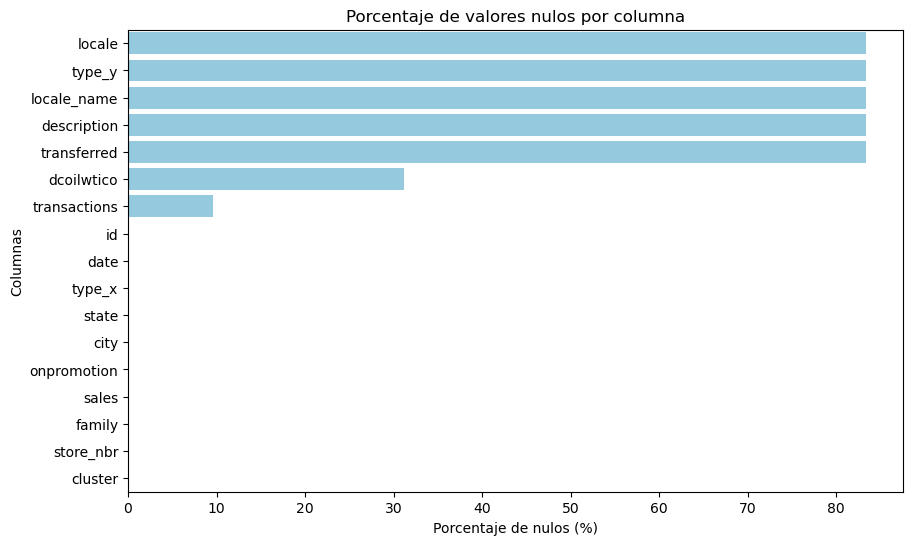

In [30]:
# Hacemos la grafica para ver mejor los nulos con su porcentaje 
porc_nulos = (df_train.isnull().sum() / len(df_train) * 100).to_frame()
porc_nulos.columns = ["porc_nulos"]

porc_nulos = porc_nulos.reset_index().rename(columns={'index': 'column'})

missing_df = porc_nulos.sort_values(by="porc_nulos", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=missing_df, x="porc_nulos", y="column", color="skyblue")

plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Porcentaje de nulos (%)")
plt.ylabel("Columnas")
plt.show()

ANÁLISIS UNIVARIANTE

Estadistica descriptiva

In [16]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
id,2443478.0,1204848.110583,0.0,603741.25,1205700.5,1807659.75,2401688.0,694412.678304
date,2443478,2014-11-09 00:28:49.571373,2013-01-01 00:00:00,2013-12-05 00:00:00,2014-11-09 00:00:00,2015-10-14 00:00:00,2016-09-12 00:00:00,NaN
store_nbr,2443478.0,27.501688,1.0,14.0,28.0,41.0,54.0,15.585511
sales,2443478.0,329.48833,0.0,0.0,8.0,179.0,124717.0,1030.691323
onpromotion,2443478.0,1.484102,0.0,0.0,0.0,0.0,741.0,9.593035
cluster,2443478.0,8.48116,1.0,4.0,8.0,13.0,17.0,4.649666
transactions,2207825.0,1703.075379,5.0,1052.0,1400.0,2108.0,8359.0,964.237372
dcoilwtico,1682564.0,72.709206,26.19,46.38,78.71,97.48,110.62,26.64742


In [ ]:
#Para ver la moda
df_train.mode().T

,0,1,2,3,4,5,6,7,8,9,...,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781
id,960498,960499,960500,960501,960502,960503,960504,960505,960506,960507,...,962270,962271,962272,962273,962274,962275,962276,962277,962278,962279
date,2014-06-25 00:00:00,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
store_nbr,35.0,36.0,40.0,41.0,42.0,43.0,44.0,45.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY II,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onpromotion,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,Quito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,Pichincha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_x,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calcular moda (elimino 'id' y 'date' ya que no aportan información relevante)
df_train.drop(columns=["id", "date"]).mode().T

,0,1,2,3,4,5,6,7
store_nbr,35,36,40,41,42,43,44,45
family,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY II,NaN
sales,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onpromotion,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,Quito,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,Pichincha,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_x,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transactions,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dcoilwtico,60.01,93.12,95.25,96.44,107.04,NaN,NaN,NaN


In [19]:
# Calcular IQR (rango intercuartilico)
df_train.describe().T["75%"] - df_train.describe().T["25%"]

id                      1203918.5
date            678 days 00:00:00
store_nbr                    27.0
sales                       179.0
onpromotion                   0.0
cluster                       9.0
transactions               1056.0
dcoilwtico                   51.1
dtype: object

In [20]:
# Calcular rango
df_train.describe().T["max"] - df_train.describe().T["min"]

id                       2401688.0
date            1350 days 00:00:00
store_nbr                     53.0
sales                     124717.0
onpromotion                  741.0
cluster                       16.0
transactions                8354.0
dcoilwtico                   84.43
dtype: object

Para sacar el skew hemos quitado la columna date, porque no es un numero int o float

In [23]:
# Calcular asimetría
"""
valor > 0 -> distribución asimétrica a la derecha
valor = 0 -> distribución simétrica
valor < 0 -> distribución asimétrica a la izquierda
"""
df_train[num_columns].skew()

id              -0.004327
store_nbr       -0.000244
sales            8.000730
onpromotion     18.164303
cluster          0.040187
transactions     1.503312
dcoilwtico      -0.101736
dtype: float64

In [24]:
# Calcular la curtosis
"""
valor > 0 -> distribución leptocúrtica
valor = 0 -> distribución mesocúrtica
valor < 0 -> distribución platicúrtica
"""
df_train[num_columns].kurt()

id               -1.205121
store_nbr        -1.200844
sales           216.084219
onpromotion     648.189125
cluster          -1.256230
transactions      2.547944
dcoilwtico       -1.704865
dtype: float64

Visualizaciones

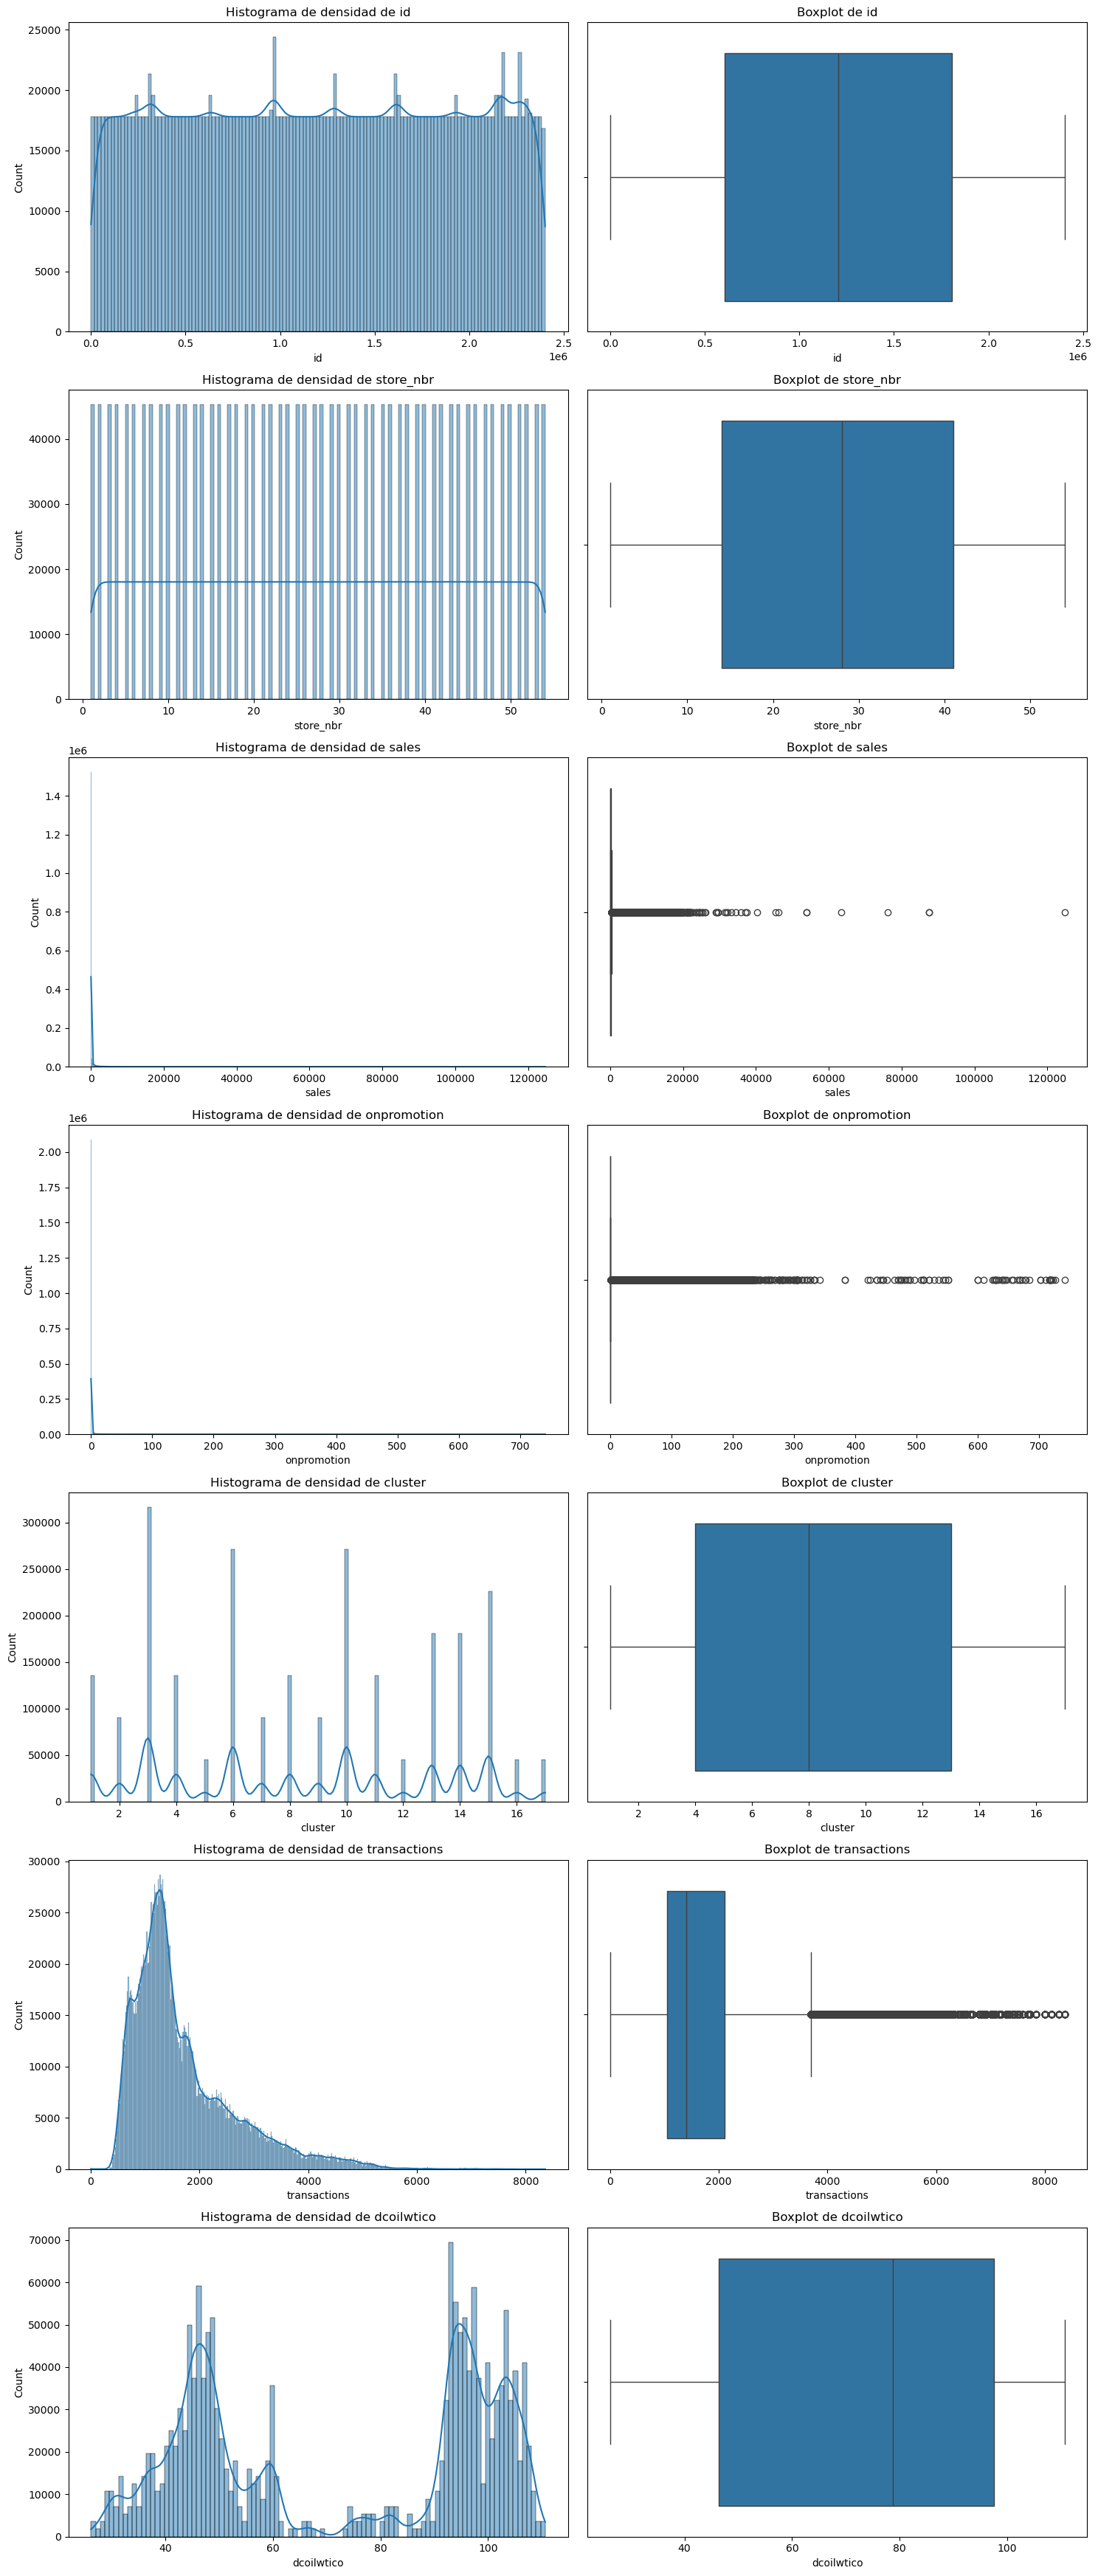

In [25]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=2, figsize=(15, 5 * len(num_columns)))

for i, column in enumerate(df_train[num_columns]):
    # Histograma de densidad
    sns.histplot(df_train[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_train[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

id: La grafica no nos explica nada, ya que es casi todo constante

store_nbr: La grafica no nos explica nada, ya que es entera constante

sales: habria que pintar otra vez la grafica con ventas de 200 para ver si hay puntos aislados

onpromotion: habria que pintar otra vez la grafica con ventas de 200 para ver si hay puntos aislados. 

cluster: 

transactions: 

dcoilwtico: si hay alguna variable que afectara al precio de la gasolina, ya que esta partido en dos

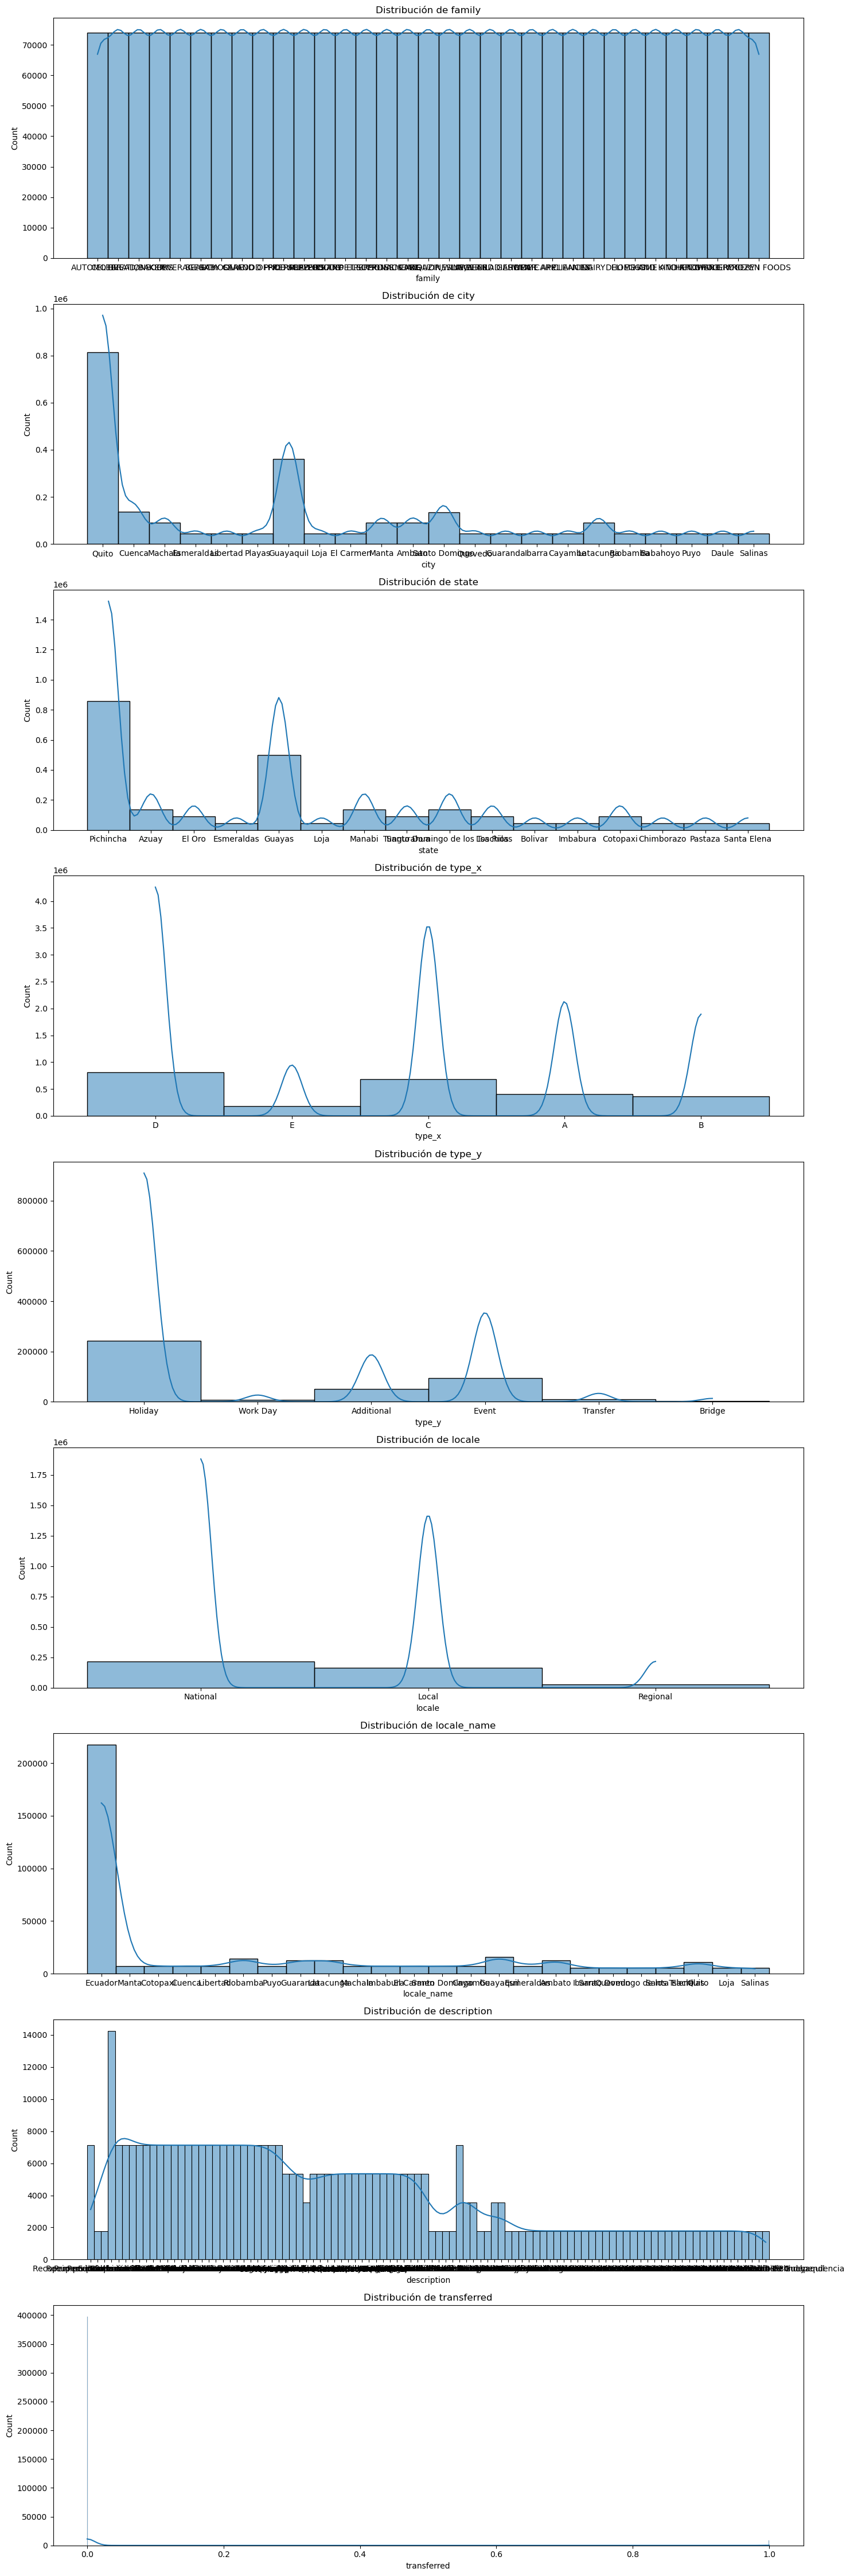

In [26]:
# Definimos la cuadrícula de una sola columna
fig, axes = plt.subplots(nrows=len(cat_columns), ncols=1, figsize=(15, 5 * len(cat_columns)))

# Si solo hay una columna, 'axes' puede no ser una lista si len(cat_columns) == 1
if len(cat_columns) == 1:
    axes = [axes]

for i, column in enumerate(cat_columns):
    # 1. Indicamos en qué eje dibujar con 'ax=axes[i]'
    sns.histplot(data=df_train, x=column, kde=True, ax=axes[i])
    
    # 2. Usamos el método correcto: axes[i].set_title
    axes[i].set_title(f'Distribución de {column}')

plt.tight_layout()
plt.show()

In [27]:
for col in cat_columns:
    print(col, df_train[col].nunique())

family 33
city 22
state 16
type_x 5
type_y 6
locale 3
locale_name 24
description 98
transferred 2


Tenemos cardinalidad, pero tampoco muy grande

Analisis bivariado

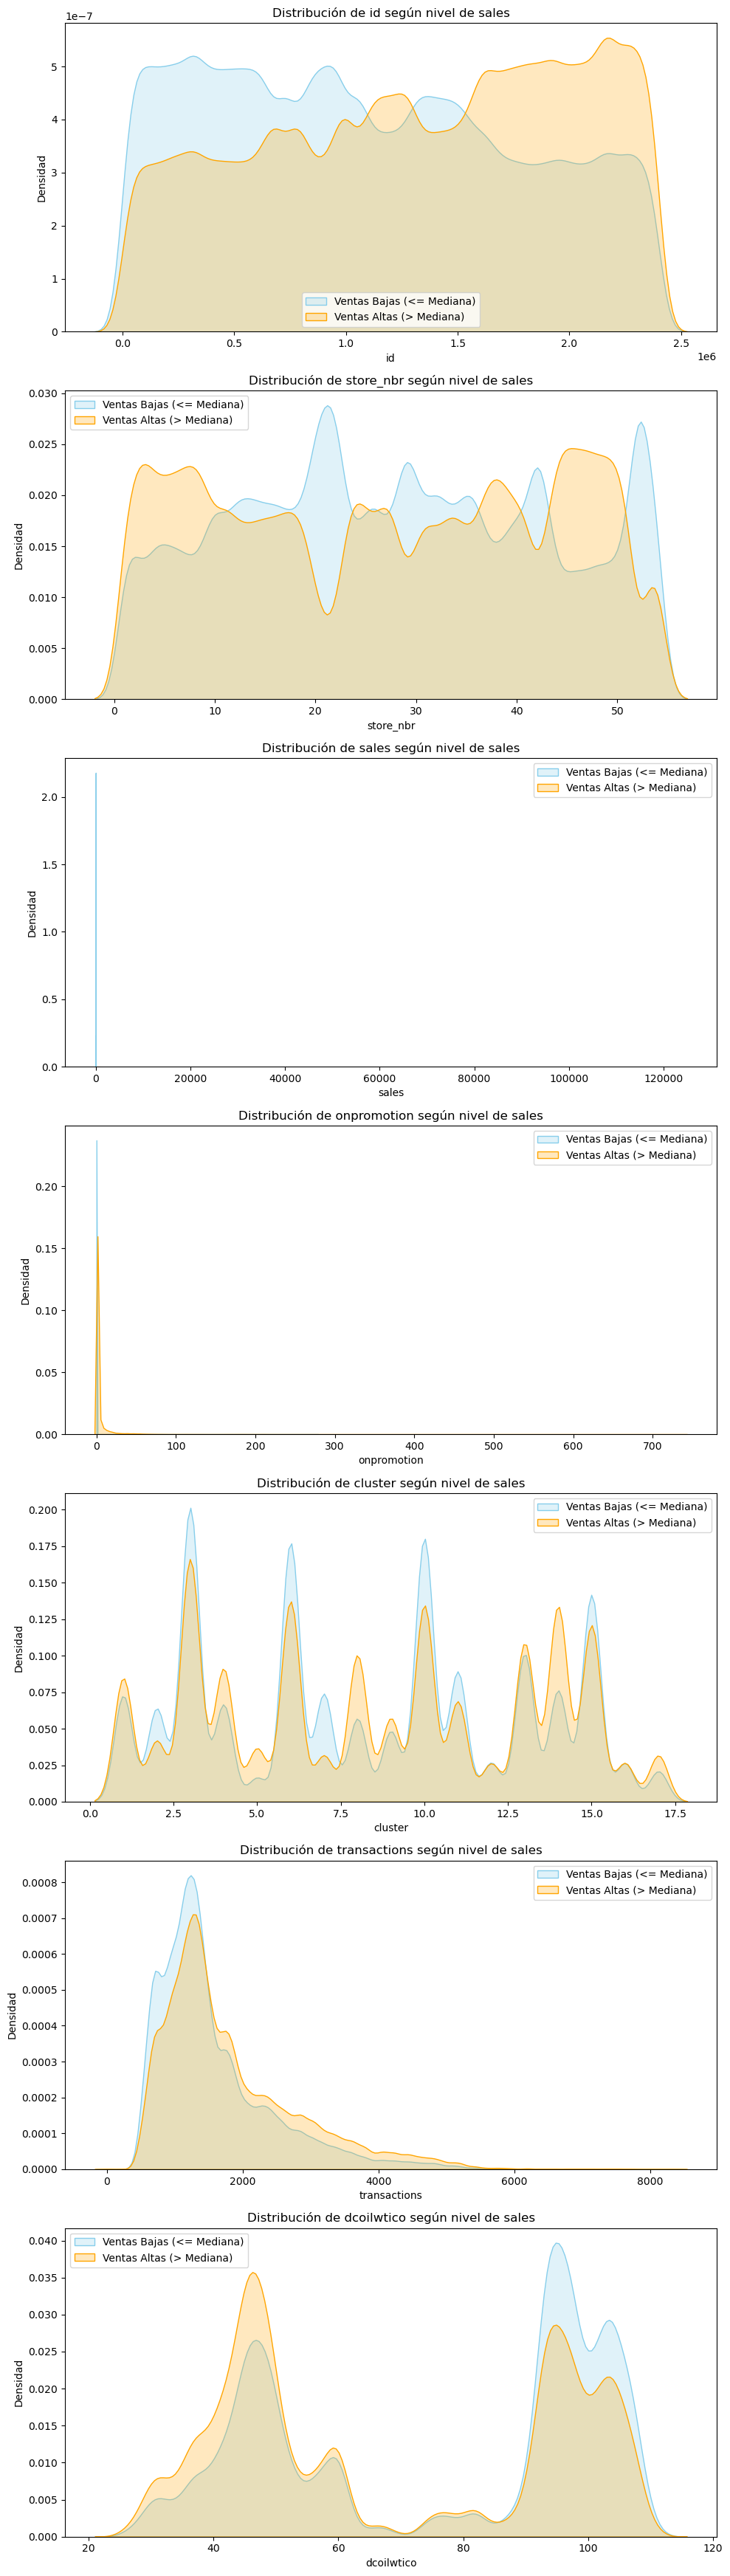

In [31]:
target="sales"

# Definir un umbral para comparar
threshold = df_train[target].median()

# Corregir plt.subplots
fig, axs = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 5 * len(num_columns)))

# Asegurarse de que axs sea una lista si solo hay una columna
if len(num_columns) == 1:
    axs = [axs]

# Graficar cada columna numérica
for i, col in enumerate(num_columns):
    # Grupo de ventas bajas
    sns.kdeplot(data=df_train[df_train[target] <= threshold], x=col, 
                ax=axs[i], label='Ventas Bajas (<= Mediana)', fill=True, color="skyblue")
    
    # Grupo de ventas altas
    sns.kdeplot(data=df_train[df_train[target] > threshold], x=col, 
                ax=axs[i], label='Ventas Altas (> Mediana)', fill=True, color="orange")
    
    axs[i].set_title(f'Distribución de {col} según nivel de {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

Analisis Multivariante

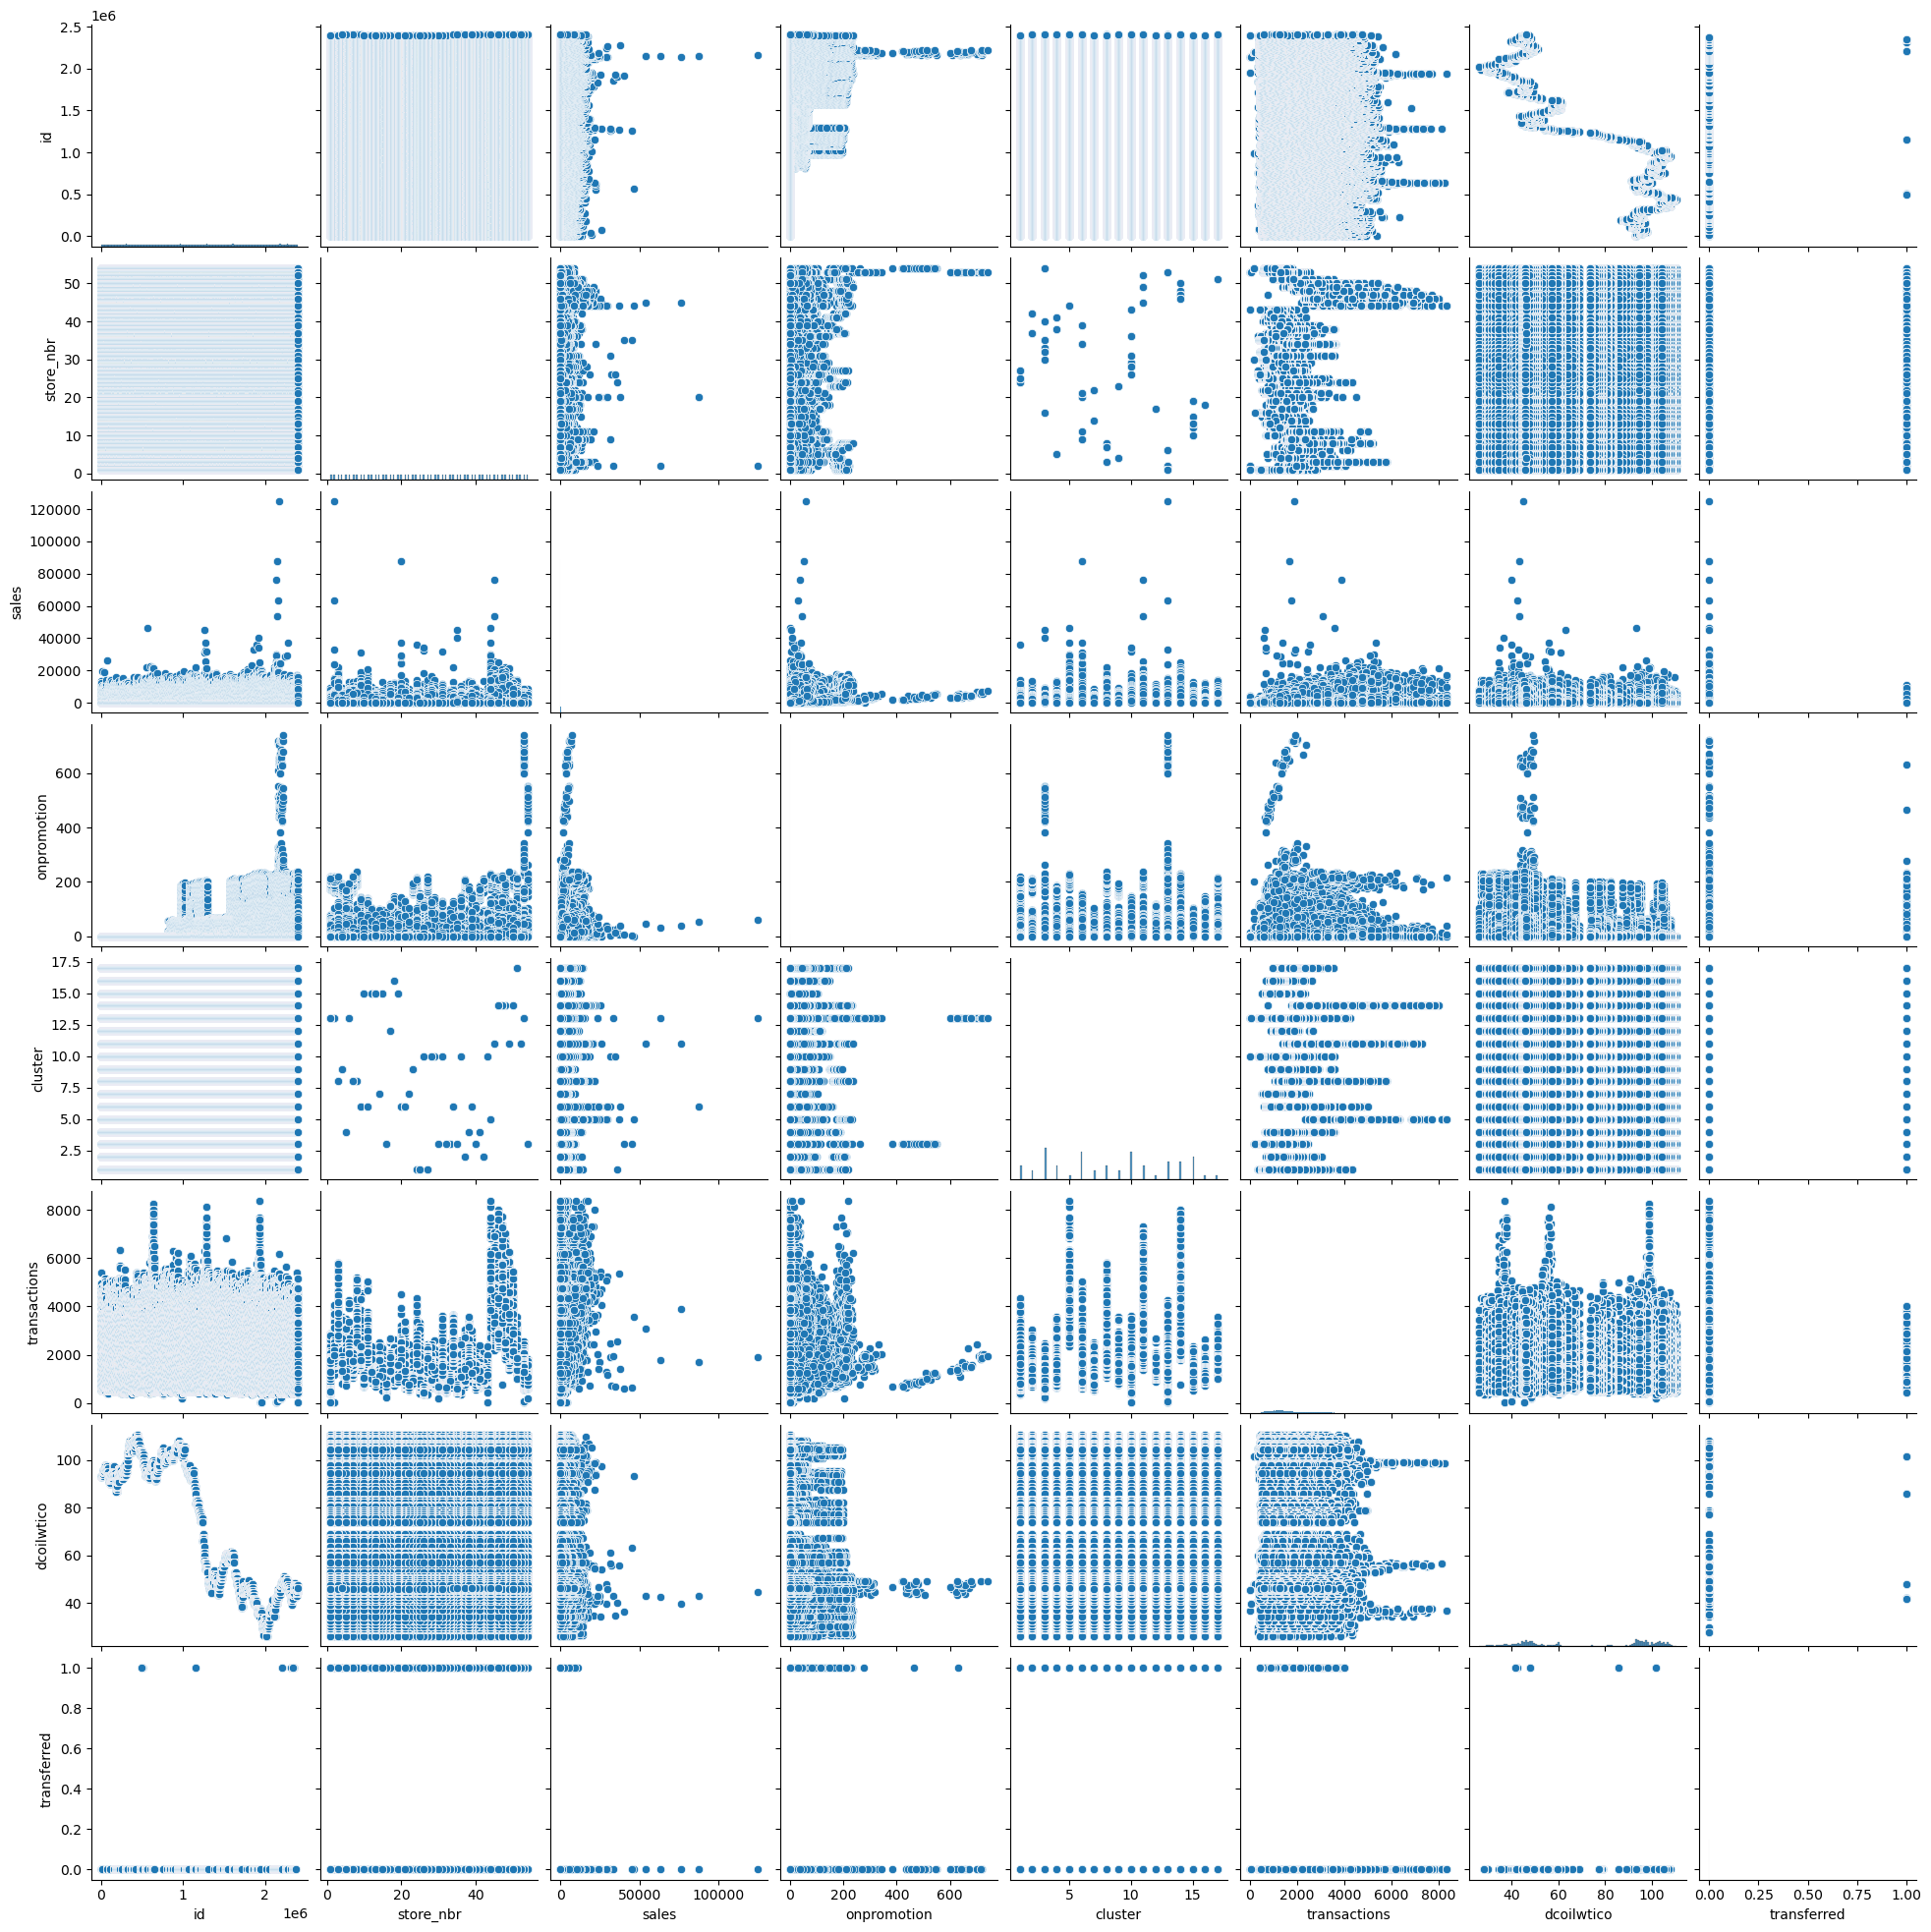

In [32]:
sns.pairplot(df_train);

In [33]:
# Correlaciones
df_train[num_columns].corr()

,id,store_nbr,sales,onpromotion,cluster,transactions,dcoilwtico
id,1.000000,0.000563,0.081777,0.156374,-0.000174,-0.031135,-0.878543
store_nbr,0.000563,1.000000,0.036671,0.010412,-0.059325,0.183609,-0.000156
sales,0.081777,0.036671,1.000000,0.316657,0.039661,0.212431,-0.076693
onpromotion,0.156374,0.010412,0.316657,1.000000,0.006096,0.019181,-0.133264
cluster,-0.000174,-0.059325,0.039661,0.006096,1.000000,0.193906,0.000100
transactions,-0.031135,0.183609,0.212431,0.019181,0.193906,1.000000,0.015430
dcoilwtico,-0.878543,-0.000156,-0.076693,-0.133264,0.000100,0.015430,1.000000


In [34]:
# Es importante eliminar nulos para el cálculo
df_oil = df_train.dropna(subset=['dcoilwtico'])

pearson = df_oil['sales'].corr(df_oil['dcoilwtico'], method='pearson')
print(f"Pearson: {pearson}")

Pearson: -0.07669271700789501


In [35]:
spearman = df_oil['sales'].corr(df_oil['dcoilwtico'], method='spearman')
print(f"Spearman: {spearman}")

Spearman: -0.1756736244598117


Observamos que la correlacion de pearson es practicamente 0, entonces no hay relacion lineal

La de Spearman es mas alta, pero sigue siendo muy debil

En conclusion las ventas y el precio del petroleo no tienen relacion lineal

Hipotesis

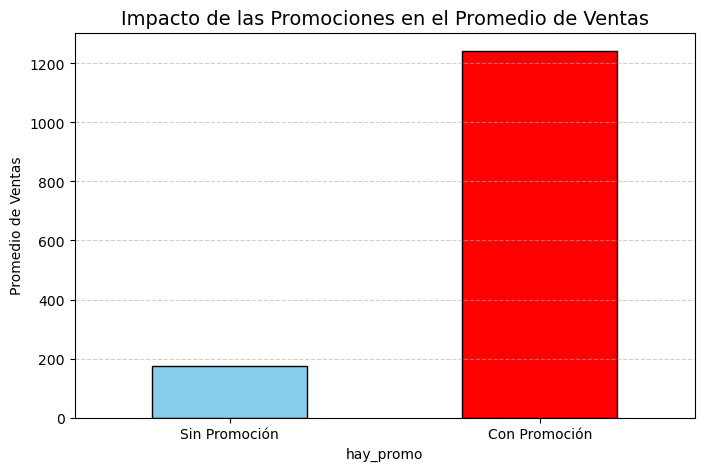

In [36]:
# 1 si hay promociones, 0 si no hay
df_train['hay_promo'] = (df_train['onpromotion'] > 0).astype(int)

# promedio de ventas para los dos
promo_impact = df_train.groupby('hay_promo')['sales'].mean()

plt.figure(figsize=(8, 5))
promo_impact.plot(kind='bar', color=['skyblue', 'red'], edgecolor='black')
plt.title('Impacto de las Promociones en el Promedio de Ventas', fontsize=14)
plt.xticks([0, 1], ['Sin Promoción', 'Con Promoción'], rotation=0)
plt.ylabel('Promedio de Ventas')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Se ve muy claramente que los productos con promociones tienen una mayor venta

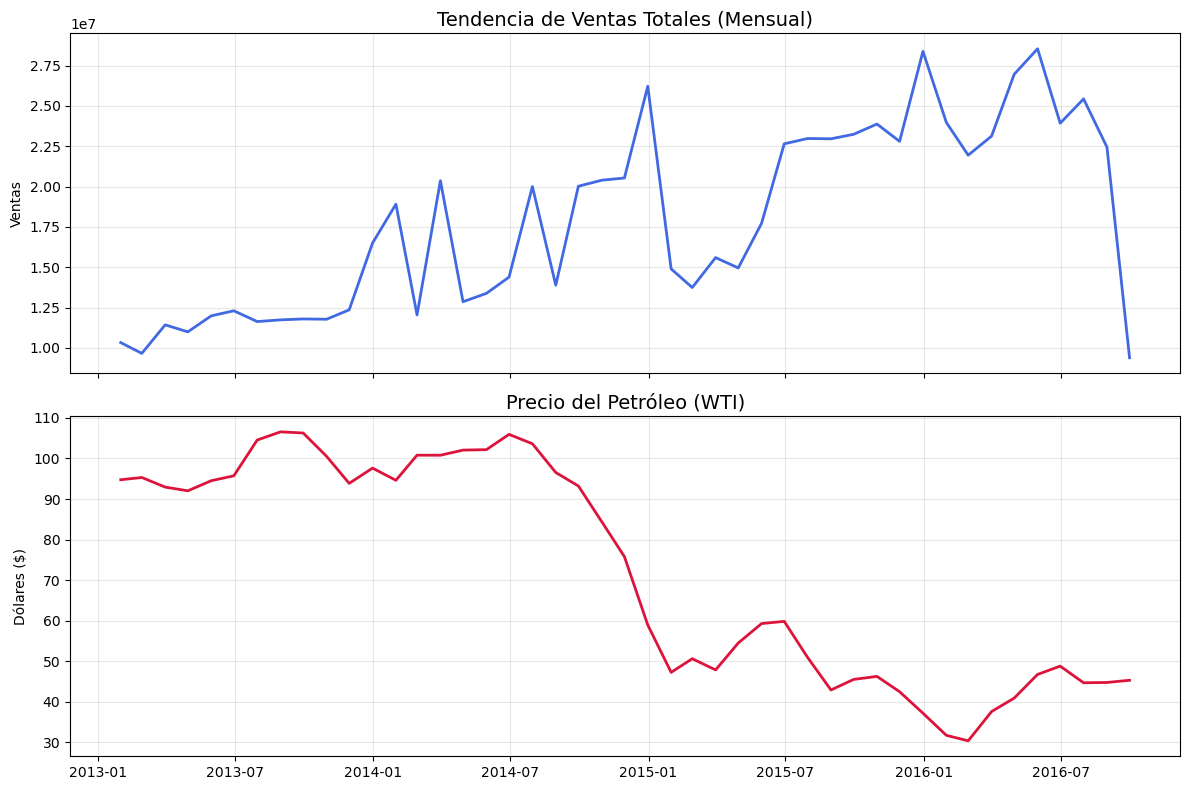

In [37]:
# 1. Preparar los datos (promedio mensual para que sea una línea clara)
data_plot = df_train.set_index('date').resample('ME').agg({'sales': 'sum', 'dcoilwtico': 'mean'})

# 2. Crear dos subgráficos (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico de arriba: VENTAS
ax1.plot(data_plot.index, data_plot['sales'], color='royalblue', linewidth=2)
ax1.set_title('Tendencia de Ventas Totales (Mensual)', fontsize=14)
ax1.set_ylabel('Ventas')
ax1.grid(True, alpha=0.3)

# Gráfico de abajo: PETRÓLEO
ax2.plot(data_plot.index, data_plot['dcoilwtico'], color='crimson', linewidth=2)
ax2.set_title('Precio del Petróleo (WTI)', fontsize=14)
ax2.set_ylabel('Dólares ($)')
ax2.grid(True, alpha=0.3)

# 3. Ajustar y mostrar
plt.tight_layout()
plt.show()

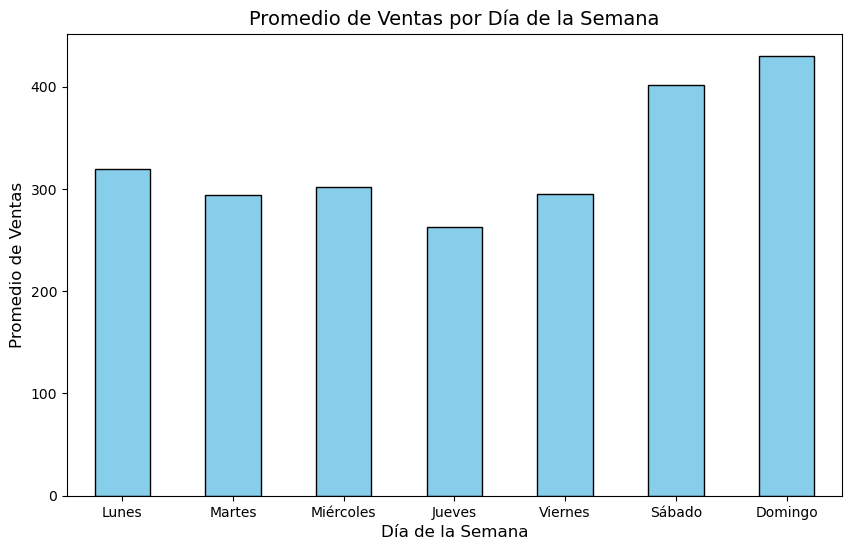

In [38]:
# Crear columna del día de la semana (0=Lunes, 6=Domingo)
df_train["dayofweek"] = df_train["date"].dt.dayofweek

# Calcular promedio de ventas por día
sales_by_day = df_train.groupby("dayofweek")["sales"].mean()

# Definir los nombres de los días
dias_nombres = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

plt.figure(figsize=(10, 6))
sales_by_day.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Promedio de Ventas por Día de la Semana", fontsize=14)
plt.xlabel("Día de la Semana", fontsize=12)
plt.ylabel("Promedio de Ventas", fontsize=12)

# Poner los nombres rectos (rotation=0) y centrados
plt.xticks(range(7), dias_nombres, rotation=0)
plt.show()

Se nota que los fines de semana hay un incremento de ventas

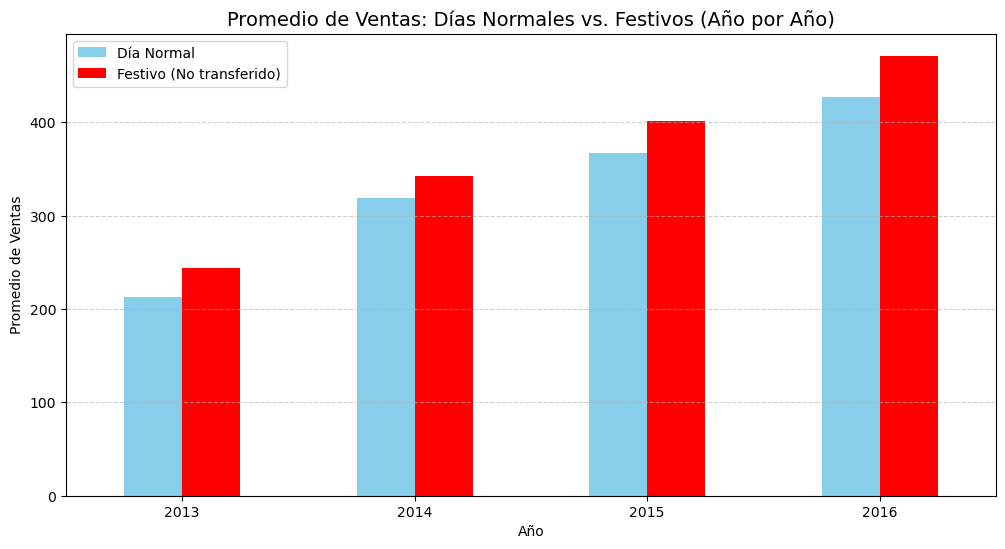

In [39]:
# Preparar feriados (sin transferidos y sin duplicados por fecha)
festivos_reales = holidays[holidays['transferred'] == False].drop_duplicates(subset=['date'])
fechas_festivas = set(festivos_reales['date'])

# Crear columnas
df_train['es_festivo'] = df_train['date'].isin(fechas_festivas).astype(int)
df_train['year'] = df_train['date'].dt.year

# promedio de ventas por Año y por tipo de Día
ventas_anuales_festivos = df_train.groupby(['year', 'es_festivo'])['sales'].mean().unstack()

plt.figure(figsize=(12, 6))
ventas_anuales_festivos.plot(kind='bar', ax=plt.gca(), color=["skyblue", 'red'])
plt.title("Promedio de Ventas: Días Normales vs. Festivos (Año por Año)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Promedio de Ventas")
plt.legend(['Día Normal', 'Festivo (No transferido)'], loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

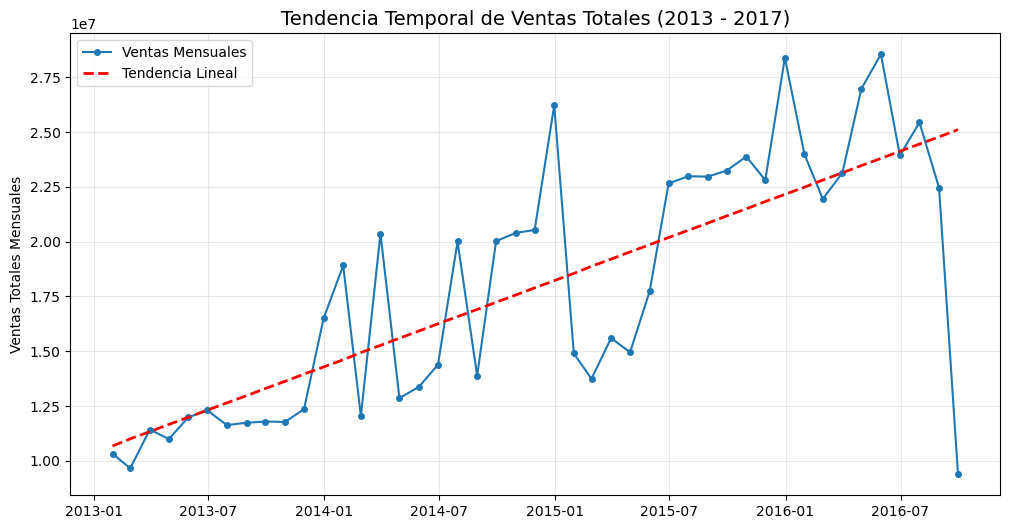

In [40]:
import numpy as np

# 1. Agrupar ventas por mes
trend_data = df_train.set_index('date').resample('ME')['sales'].sum()

# 2. Crear la gráfica base
plt.figure(figsize=(12, 6))
plt.plot(trend_data.index, trend_data.values, label='Ventas Mensuales', marker='o', markersize=4)

# 3. Calcular la línea de tendencia usando un índice numérico (0 a N)
x_numeric = np.arange(len(trend_data)) 
y_values = trend_data.values

z = np.polyfit(x_numeric, y_values, 1)
p = np.poly1d(z)

# 4. Dibujar la línea roja sobre las fechas originales
plt.plot(trend_data.index, p(x_numeric), "r--", linewidth=2, label="Tendencia Lineal")

# 5. Configuración final
plt.title('Tendencia Temporal de Ventas Totales (2013 - 2017)', fontsize=14)
plt.ylabel('Ventas Totales Mensuales')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Evolucion temporal, es para ver los patrones estacionales, hay picos en fechas especificas 